# **1. Import Libraries**

In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, f1_score


# **2. Read Data**

In [ ]:
df = pd.read_csv(r"/content/heart_patients_dirty_dataset.csv")

print("Original Dataset:")
df.head(5)


Original Dataset:


,Patient_ID,Age,Gender,Chest_Pain_Type,Resting_BP_mmHg,Cholesterol_mg/dl,Max_Heart_Rate,ST_Depression,Exercise_Induced_Angina,Heart_Disease
0,524.0,87.0,NaN,NaN,151.343081,162.378238,162.287641,2.801430,Yes,zero
1,603.0,66.0,male,NaN,101.214098,218.380992,155.846201,0.182318,No,zero
2,527.0,87.0,FEMALE,Atypical Angina,150.354093,248.765623,195.335192,0.875113,yes,1
3,32.0,87.0,FEMALE,Non-Anginal Pain,124.865389,NaN,180.730370,0.300505,yes,NaN
4,617.0,45.0,NaN,Typical Angina,112.437303,211.572296,121.968906,NaN,No,one


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               1005 non-null   float64
 1   Age                      1005 non-null   object 
 2   Gender                   804 non-null    object 
 3   Chest_Pain_Type          798 non-null    object 
 4   Resting_BP_mmHg          1004 non-null   float64
 5   Cholesterol_mg/dl        1005 non-null   float64
 6   Max_Heart_Rate           1004 non-null   float64
 7   ST_Depression            995 non-null    float64
 8   Exercise_Induced_Angina  801 non-null    object 
 9   Heart_Disease            782 non-null    object 
dtypes: float64(5), object(5)
memory usage: 79.8+ KB


In [ ]:
df.shape

(1020, 10)

# **3. Check for Duplicate & Null values**

In [ ]:
before = len(df)
df.drop_duplicates(keep='first', inplace=True)
print(f'Removed {before - len(df)} duplicates. Rows remaining: {len(df)}')

Removed 20 duplicates. Rows remaining: 1000


In [ ]:
df.isnull().sum()

,0
Patient_ID,15
Age,15
Gender,213
Chest_Pain_Type,220
Resting_BP_mmHg,15
Cholesterol_mg/dl,15
Max_Heart_Rate,15
ST_Depression,25
Exercise_Induced_Angina,217
Heart_Disease,231


# **4. Handle the missing values**

In [ ]:
num_cols = ['Age','Resting_BP_mmHg','Cholesterol_mg/dl',
            'Max_Heart_Rate','ST_Depression']

df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [ ]:
cat_cols = ['Gender','Chest_Pain_Type',
            'Exercise_Induced_Angina','Heart_Disease']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df = df.dropna(subset=['Patient_ID'])

In [ ]:
df.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
Chest_Pain_Type,0
Resting_BP_mmHg,0
Cholesterol_mg/dl,0
Max_Heart_Rate,0
ST_Depression,0
Exercise_Induced_Angina,0
Heart_Disease,0


# **5. Handle the Inconsistent Data**

In [ ]:
df['Gender'] = df['Gender'].str.lower()
df['Exercise_Induced_Angina'] = df['Exercise_Induced_Angina'].str.lower()

In [ ]:
df['Heart_Disease'] = df['Heart_Disease'].replace({
    'zero':0,
    'one':1
})

In [ ]:
df[['Patient_ID', 'Age']] = df[['Patient_ID', 'Age']].astype(int)

In [ ]:
df.head()

,Patient_ID,Age,Gender,Chest_Pain_Type,Resting_BP_mmHg,Cholesterol_mg/dl,Max_Heart_Rate,ST_Depression,Exercise_Induced_Angina,Heart_Disease
0,524,87,male,Asymptomatic,151.343081,162.378238,162.287641,2.801430,yes,0
1,603,66,male,Asymptomatic,101.214098,218.380992,155.846201,0.182318,no,0
2,527,87,female,Atypical Angina,150.354093,248.765623,195.335192,0.875113,yes,1
3,32,87,female,Non-Anginal Pain,124.865389,201.701371,180.730370,0.300505,yes,0
4,617,45,male,Typical Angina,112.437303,211.572296,121.968906,0.985730,no,1


# **6. Check for Outliers**

In [ ]:
num_cols = ['Age','Resting_BP_mmHg','Cholesterol_mg/dl',
            'Max_Heart_Rate','ST_Depression']

outlier_counts = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_counts[col] = len(outliers)

for col, count in outlier_counts.items():
    print(f"{col}: {count} outliers")

Age: 0 outliers
Resting_BP_mmHg: 28 outliers
Cholesterol_mg/dl: 25 outliers
Max_Heart_Rate: 22 outliers
ST_Depression: 12 outliers


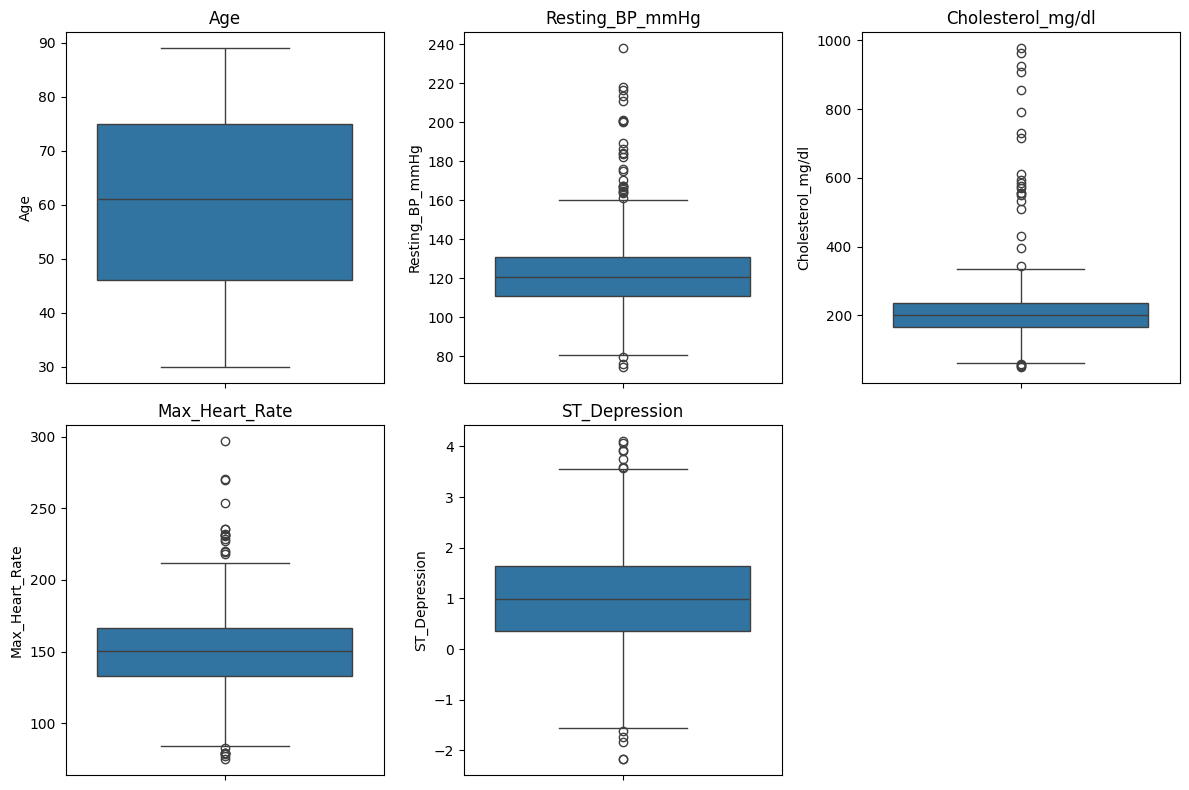

In [ ]:
num_cols = ['Age','Resting_BP_mmHg','Cholesterol_mg/dl',
            'Max_Heart_Rate','ST_Depression']

plt.figure(figsize=(12,8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# **7. Remove the Outliers**

In [ ]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

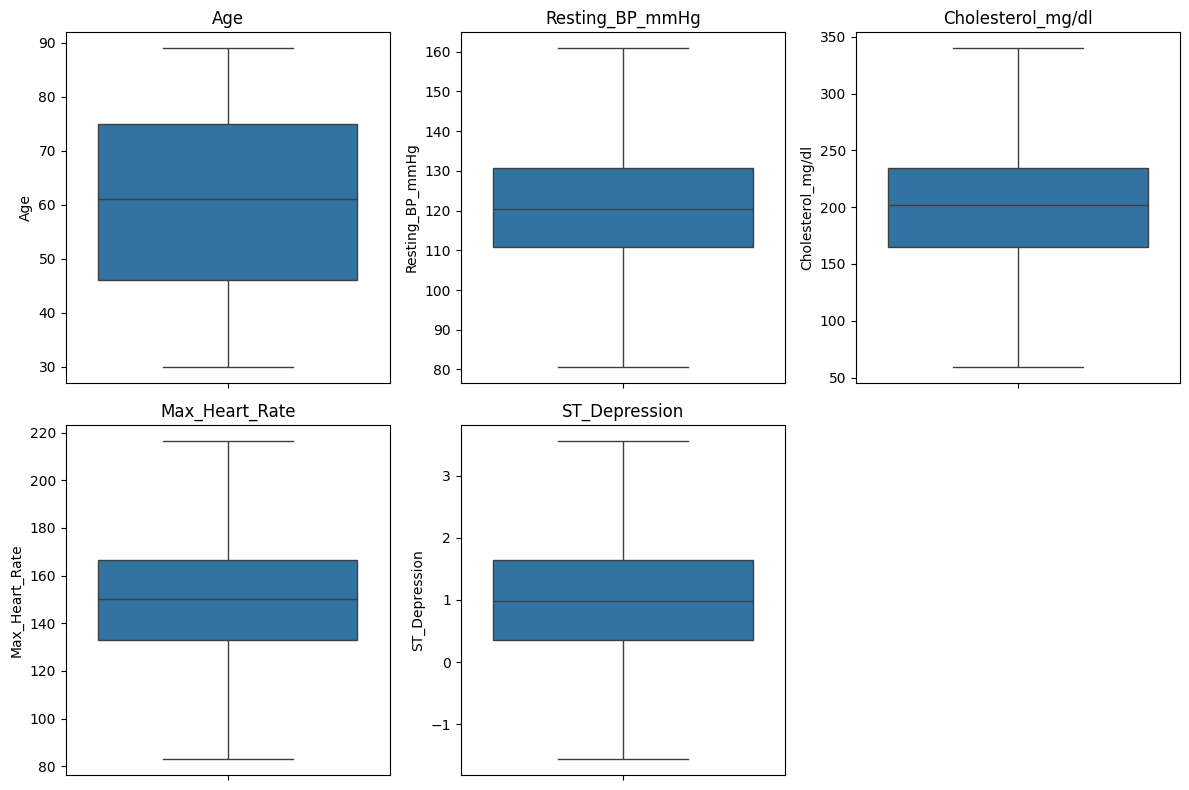

In [ ]:
num_cols = ['Age','Resting_BP_mmHg','Cholesterol_mg/dl',
            'Max_Heart_Rate','ST_Depression']

plt.figure(figsize=(12,8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# **8. Data Encoding**

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['Exercise_Induced_Angina'] = le.fit_transform(df['Exercise_Induced_Angina'])

# one-hot encode Chest Pain Type
df = pd.get_dummies(df, columns=['Chest_Pain_Type'])


In [ ]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# **9. Feature Scailing**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

num_cols = ['Age','Resting_BP_mmHg','Cholesterol_mg/dl',
            'Max_Heart_Rate','ST_Depression']

df[num_cols] = scaler.fit_transform(df[num_cols])

In [ ]:
df.head()

,Patient_ID,Age,Gender,Resting_BP_mmHg,Cholesterol_mg/dl,Max_Heart_Rate,ST_Depression,Exercise_Induced_Angina,Heart_Disease,Chest_Pain_Type_Asymptomatic,Chest_Pain_Type_Atypical Angina,Chest_Pain_Type_Non-Anginal Pain,Chest_Pain_Type_Typical Angina
0,524,1.559252,1,1.938766,-0.744969,0.489252,1.878399,1,0,1,0,0,0
1,603,0.337219,1,-1.290584,0.304530,0.238413,-0.829296,0,0,1,0,0,0
2,527,1.559252,0,1.875054,0.873942,1.776175,-0.113069,1,1,0,1,0,0
3,32,1.559252,0,0.233051,-0.008048,1.207440,-0.707112,1,0,0,0,1,0
4,617,-0.884815,1,-0.567576,0.176934,-1.080821,0.001289,0,1,0,0,0,1


In [ ]:
df['Heart_Disease']=df['Heart_Disease'].astype(int)

# **10. Train the Model**

In [ ]:
X = df.drop('Heart_Disease', axis=1)
y = df['Heart_Disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

# **11. Evaluate the Accuracy of the Model**

In [ ]:
y_pred = model.predict(X_test)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc:.4f}")

f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.4f}")

y_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")



Confusion Matrix:
[[119   3]
 [ 72   3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.98      0.76       122
           1       0.50      0.04      0.07        75

    accuracy                           0.62       197
   macro avg       0.56      0.51      0.42       197
weighted avg       0.58      0.62      0.50       197


Accuracy: 0.6193
F1 Score: 0.0741
ROC-AUC Score: 0.5851


# **12. Check for Overfitting / Underfitting**

In [ ]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.6091370558375635
Test Accuracy: 0.6192893401015228


# **13. Check for the Important Features ( Feature Selection )**

In [ ]:
importance = model.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Use absolute values (important for interpretation)
feature_importance['Importance'] = feature_importance['Importance'].abs()

# Convert to percentage
feature_importance['Importance (%)'] = (
    feature_importance['Importance'] /
    feature_importance['Importance'].sum()
) * 100

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by='Importance (%)', ascending=False
)

print(feature_importance)

                             Feature  Importance  Importance (%)
10  Chest_Pain_Type_Non-Anginal Pain    0.154126       17.938845
3                    Resting_BP_mmHg    0.143030       16.647322
2                             Gender    0.118479       13.789874
11    Chest_Pain_Type_Typical Angina    0.098539       11.468967
5                     Max_Heart_Rate    0.090631       10.548562
1                                Age    0.081807        9.521618
4                  Cholesterol_mg/dl    0.068215        7.939568
6                      ST_Depression    0.057147        6.651374
9    Chest_Pain_Type_Atypical Angina    0.021055        2.450644
8       Chest_Pain_Type_Asymptomatic    0.014131        1.644714
7            Exercise_Induced_Angina    0.011983        1.394763
0                         Patient_ID    0.000032        0.003750


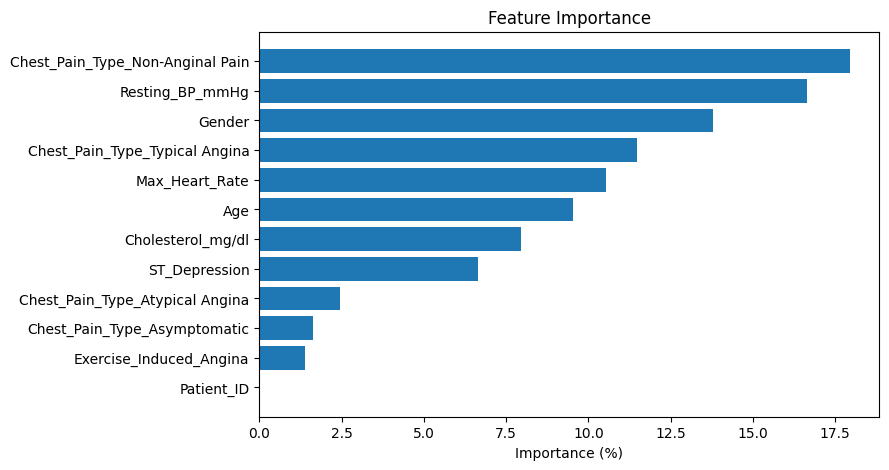

In [ ]:
plt.figure(figsize=(8,5))
plt.barh(feature_importance['Feature'], feature_importance['Importance (%)'])
plt.xlabel("Importance (%)")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

# **14. Check for the model accuracy after removing the less important Features**

In [ ]:
low_importance_features = [
    'Gender',
    'Exercise_Induced_Angina',
    'Chest_Pain_Type_Asymptomatic',
    'Chest_Pain_Type_Atypical Angina',
    'Chest_Pain_Type_Non-Anginal Pain',
    'Chest_Pain_Type_Typical Angina'
]

df = df.drop(columns=low_importance_features, errors='ignore')
df = df.drop(columns=['Patient_ID'], errors='ignore')

X = df.drop('Heart_Disease', axis=1)
y = df['Heart_Disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy after feature removal:", accuracy)

Logistic Regression Accuracy after feature removal: 0.6192893401015228


Note - Getting the same accuracy after removing low-importance features means the removed features had almost no effect on the output.